# 8.1 — Superficie de volatilidad implícita: arbitraje estático y SVI

Arranca M8. La superficie de volatilidad implícita $\sigma(K,T)$ no es un objeto libre:
para que los precios de vainilla que implica sean consistentes con no-arbitraje, debe
satisfacer dos condiciones estructurales (calendario y butterfly). La parametrización
**SVI** (Gatheral, 2004) da una forma funcional de 5 parámetros por vencimiento que, con
las restricciones adecuadas, es fácil de mantener arbitrage-free y de calibrar a
mercado.

## 0. Configuración

In [1]:
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registra el proyector 3d)

from qflib.market import svi_total_variance
from qflib.black import bs_price, implied_vol, bs_delta, bs_vega
from qflib.plotting import apply_style
from scipy.stats import norm

apply_style()
rng = np.random.default_rng(42)

## 1. Total variance y las condiciones de no-arbitraje estático

Se trabaja en **total variance** $w(k,T)=\sigma^2(k,T)\,T$ sobre el log-moneyness
$k=\ln(K/F_T)$ ($F_T$ el forward a $T$) en vez de en $\sigma(K,T)$ directamente: la
condición de calendario es más simple ($w$ no decreciente en $T$) y la de butterfly evita
dividir por $T$ explícitamente.

**Calendario**: para cada $k$ fijo, $w(k,T_1)\le w(k,T_2)$ si $T_1<T_2$ — si no, dos
vencimientos implicarían una probabilidad negativa para algún evento (comprar la opción
de vencimiento corto y vender la de vencimiento largo al mismo strike sería un arbitraje
estático).

**Butterfly (condición de Durrleman)**: la densidad risk-neutral de Breeden-Litzenberger
implícita en $w(\cdot,T)$ debe ser no negativa. En términos de $w$ y sus derivadas en $k$:
$$g(k) = \left(1-\frac{k\,w'(k)}{2w(k)}\right)^2 - \frac{w'(k)^2}{4}\left(\frac{1}{w(k)}+\frac14\right) + \frac{w''(k)}{2} \ge 0 \quad \forall k$$

**SVI cruda** (Gatheral 2004):
$$w(k) = a + b\left(\rho(k-m) + \sqrt{(k-m)^2+\sigma^2}\right)$$
con $b\ge0$, $|\rho|<1$, $\sigma>0$ y $a+b\sigma\sqrt{1-\rho^2}\ge0$ (mínimo de $w$ no
negativo) como condiciones necesarias de sensatez. Ya implementada en
`qflib.market.svi_total_variance`.

In [2]:
def durrleman_g(k, w_func, dk=1e-4):
    '''Condicion de Durrleman g(k) en total variance (Seccion 1).'''
    w = w_func(k)
    wp = (w_func(k + dk) - w_func(k - dk)) / (2 * dk)
    wpp = (w_func(k + dk) - 2 * w + w_func(k - dk)) / dk ** 2
    term1 = (1.0 - k * wp / (2.0 * w)) ** 2
    term2 = (wp ** 2 / 4.0) * (1.0 / w + 0.25)
    term3 = wpp / 2.0
    return term1 - term2 + term3


k_grid = np.linspace(-1.5, 1.5, 301)

### Demo 1 — superficie SVI arbitrage-free por construcción

Construimos una superficie de 5 vencimientos usando `svi_params(T)`, con los 5 parámetros de SVI variando suavemente (y de forma creciente) en $T$ — a propósito, para que la superficie resultante NO viole la condición de calendario. Graficamos el smile por vencimiento y la superficie completa en 3D.

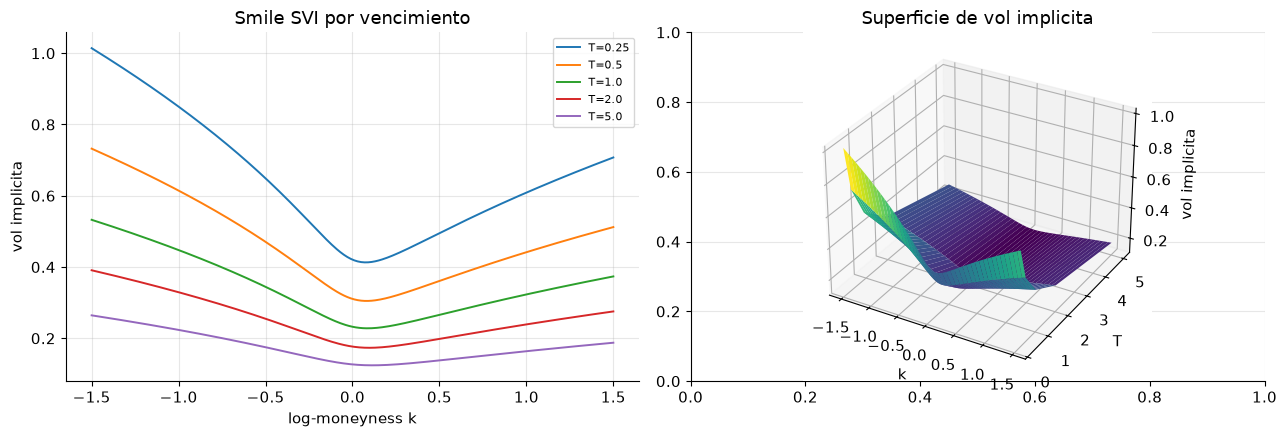

In [3]:
Ts = np.array([0.25, 0.5, 1.0, 2.0, 5.0])


def svi_params(T):
    '''Parametros SVI variando suavemente en T (Demo 1): construidos para NO violar calendario.'''
    a = 0.02 + 0.01 * np.sqrt(T)
    b = 0.10 + 0.02 * np.sqrt(T)
    rho = -0.4
    m = 0.0
    sigma = 0.15 + 0.05 * np.sqrt(T)
    return a, b, rho, m, sigma


W = np.zeros((len(Ts), len(k_grid)))
for i, T in enumerate(Ts):
    a, b, rho, m, sigma = svi_params(T)
    W[i, :] = svi_total_variance(k_grid, a=a, b=b, rho=rho, m=m, sigma=sigma)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i, T in enumerate(Ts):
    axes[0].plot(k_grid, np.sqrt(W[i] / T), label=f"T={T}")
axes[0].set_xlabel("log-moneyness k"); axes[0].set_ylabel("vol implicita")
axes[0].set_title("Smile SVI por vencimiento"); axes[0].legend(fontsize=8)

ax3d = fig.add_subplot(1, 2, 2, projection="3d")
Kg, Tg = np.meshgrid(k_grid, Ts)
ax3d.plot_surface(Kg, Tg, np.sqrt(W / Tg), cmap="viridis")
ax3d.set_xlabel("k"); ax3d.set_ylabel("T"); ax3d.set_zlabel("vol implicita")
ax3d.set_title("Superficie de vol implicita")
fig.tight_layout(); plt.show()

### Demo 2 — verificación de calendario y butterfly sobre toda la malla

Verificamos numéricamente, sobre la superficie recién construida, que se cumplen las dos condiciones de la Sección 1: $w$ no decreciente en $T$ para cada $k$ (calendario), y $g(k)\ge0$ en cada vencimiento (butterfly, vía la condición de Durrleman) — las dos propiedades que garantizan que la superficie no admite arbitraje estático.

In [4]:
calendar_ok = np.all(np.diff(W, axis=0) >= -1e-10)
print(f"calendario (w no decreciente en T, para cada k): {calendar_ok}")

butterfly_ok_by_T = []
for T in Ts:
    a, b, rho, m, sigma = svi_params(T)
    w_func = lambda k, a=a, b=b, rho=rho, m=m, sigma=sigma: svi_total_variance(k, a=a, b=b, rho=rho, m=m, sigma=sigma)
    g = durrleman_g(k_grid[10:-10], w_func)
    ok = np.all(g >= -1e-6)
    butterfly_ok_by_T.append(ok)
    print(f"T={T}: butterfly (Durrleman g>=0) = {ok} (min g = {g.min():.4f})")

butterfly_ok = all(butterfly_ok_by_T)
print(f"\nbutterfly ok en todos los vencimientos: {butterfly_ok}")

calendario (w no decreciente en T, para cada k): True
T=0.25: butterfly (Durrleman g>=0) = True (min g = 0.2847)
T=0.5: butterfly (Durrleman g>=0) = True (min g = 0.2868)
T=1.0: butterfly (Durrleman g>=0) = True (min g = 0.2895)
T=2.0: butterfly (Durrleman g>=0) = True (min g = 0.2930)
T=5.0: butterfly (Durrleman g>=0) = True (min g = 0.2993)

butterfly ok en todos los vencimientos: True


### Demo 3 — control negativo: una superficie con calendario invertido debe fallar el chequeo

Construimos deliberadamente una superficie con el parámetro `a(T)` en el orden INVERSO (decreciente en $T$ en vez de creciente) — esto viola calendario a propósito. Si el chequeo de la Demo 2 está bien implementado, debe detectar esta violación (no basta con que pase superficies buenas; también tiene que rechazar las malas).

calendario en la superficie CON arbitraje intencional: False (debe ser False -- el chequeo SI detecta la violacion)


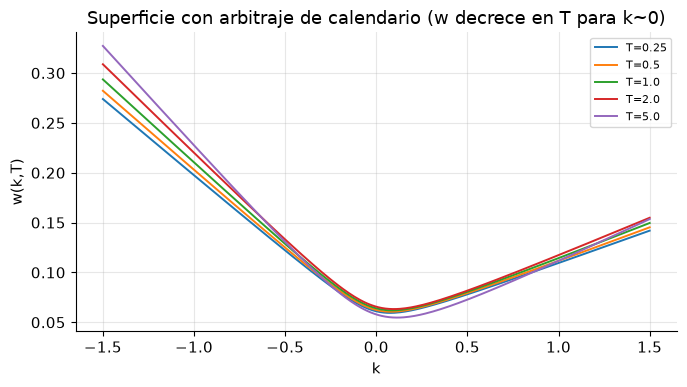

In [5]:
def svi_params_bad(T, T_max=5.0):
    '''Igual que svi_params pero con 'a' en orden INVERTIDO en T -- viola calendario a proposito.'''
    a = 0.02 + 0.01 * np.sqrt(T_max - T)
    b = 0.10 + 0.02 * np.sqrt(T)
    rho = -0.4
    m = 0.0
    sigma = 0.15 + 0.05 * np.sqrt(T)
    return a, b, rho, m, sigma


W_bad = np.zeros((len(Ts), len(k_grid)))
for i, T in enumerate(Ts):
    a, b, rho, m, sigma = svi_params_bad(T)
    W_bad[i, :] = svi_total_variance(k_grid, a=a, b=b, rho=rho, m=m, sigma=sigma)

calendar_bad_ok = np.all(np.diff(W_bad, axis=0) >= -1e-10)
print(f"calendario en la superficie CON arbitraje intencional: {calendar_bad_ok} "
      f"(debe ser False -- el chequeo SI detecta la violacion)")

fig, ax = plt.subplots(figsize=(7, 4))
for i, T in enumerate(Ts):
    ax.plot(k_grid, W_bad[i], label=f"T={T}")
ax.set_xlabel("k"); ax.set_ylabel("w(k,T)")
ax.set_title("Superficie con arbitraje de calendario (w decrece en T para k~0)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

### Demo 3b — control negativo simétrico: una superficie con arbitraje de mariposa debe fallar el chequeo de Durrleman

La Demo 3 probó el control negativo de calendario; falta el simétrico para butterfly. La Demo 2 sólo mostró que `durrleman_g` da $g\ge0$ en una superficie ya construida para ser sensata — pero eso no prueba que el chequeo sea capaz de detectar una violación cuando de verdad la hay. Un smile SVI demasiado pronunciado (curvatura grande, controlada por $b$, combinada con $\sigma$ pequeño y $|\rho|$ cerca de 1) puede producir una densidad de Breeden-Litzenberger negativa en algún $k$, aunque los parámetros individuales sigan cumpliendo las restricciones "de sensatez" de la Sección 1 ($b\ge0$, $|\rho|<1$, $\sigma>0$, mínimo de $w$ no negativo) — esas restricciones son necesarias pero no suficientes para ausencia de arbitraje de mariposa. Construimos deliberadamente una superficie así (un único vencimiento, no hace falta la cadena completa) y verificamos que `durrleman_g` sí produce valores negativos y que el chequeo de la Sección 1 la rechaza.

parametros: {'a': 0.02, 'b': 1.0, 'rho': -0.95, 'm': 0.0, 'sigma': 0.05}
min Durrleman g en la superficie CON arbitraje intencional: -2.7159
butterfly ok (debe ser False -- el chequeo SI detecta la violacion): False


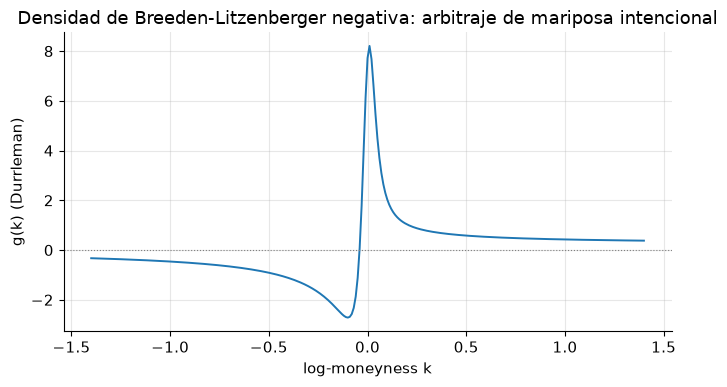

In [6]:
params_butterfly_bad = dict(a=0.02, b=1.0, rho=-0.95, m=0.0, sigma=0.05)  # b grande, sigma chico, |rho| cerca de 1


def w_func_bad(k, p=params_butterfly_bad):
    return svi_total_variance(k, **p)


g_bad = durrleman_g(k_grid[10:-10], w_func_bad)
butterfly_bad_ok = np.all(g_bad >= -1e-6)
print(f"parametros: {params_butterfly_bad}")
print(f"min Durrleman g en la superficie CON arbitraje intencional: {g_bad.min():.4f}")
print(f"butterfly ok (debe ser False -- el chequeo SI detecta la violacion): {butterfly_bad_ok}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_grid[10:-10], g_bad)
ax.axhline(0.0, color="gray", lw=0.8, ls=":")
ax.set_xlabel("log-moneyness k"); ax.set_ylabel("g(k) (Durrleman)")
ax.set_title("Densidad de Breeden-Litzenberger negativa: arbitraje de mariposa intencional")
fig.tight_layout(); plt.show()

## 2. Calibración de SVI a un smile de mercado

Recuperar los parámetros SVI verdaderos a partir de precios: se genera un smile con
`svi_params` a un vencimiento fijo, se convierte a precios Black-Scholes, se invierte de
vuelta a vol implícita (control de round-trip: `implied_vol(bs_price(...))` debe
reproducir la vol de entrada a máquina-epsilon), y se recalibra SVI con mínimos cuadrados
sobre esas vols — sin ruido, el problema está exactamente identificado y debe recuperar
los 5 parámetros originales.

In [7]:
T_cal = 1.0
a_true, b_true, rho_true, m_true, sigma_true = svi_params(T_cal)
F0 = 100.0
strikes = F0 * np.exp(np.linspace(-0.6, 0.6, 15))
k_obs = np.log(strikes / F0)

w_true = svi_total_variance(k_obs, a=a_true, b=b_true, rho=rho_true, m=m_true, sigma=sigma_true)
iv_true = np.sqrt(w_true / T_cal)

prices = np.array([bs_price(F0, K, 0.0, 0.0, iv, T_cal, kind="call") for K, iv in zip(strikes, iv_true)])
iv_recovered = np.array([implied_vol(p, F0, K, 0.0, 0.0, T_cal, kind="call") for p, K in zip(prices, strikes)])
max_diff_roundtrip = np.max(np.abs(iv_recovered - iv_true))
print(f"round-trip precio->vol (debe ser ~0, maquina-epsilon): {max_diff_roundtrip:.2e}")


def resid_svi(params):
    a, b, rho, m, sigma = params
    if b < 0.0 or abs(rho) >= 1.0 or sigma <= 0.0:
        return np.full(len(k_obs), 1e3)
    w_model = svi_total_variance(k_obs, a=a, b=b, rho=rho, m=m, sigma=sigma)
    return np.sqrt(w_model / T_cal) - iv_recovered


fit = least_squares(resid_svi, x0=[0.01, 0.05, 0.0, 0.0, 0.3],
                     bounds=([-1.0, 0.0, -0.999, -2.0, 1e-4], [1.0, 2.0, 0.999, 2.0, 5.0]))
a_f, b_f, rho_f, m_f, sigma_f = fit.x
true_params = np.array([a_true, b_true, rho_true, m_true, sigma_true])
fit_params = fit.x
print(f"\nparametros verdaderos:   a={a_true:.5f}, b={b_true:.5f}, rho={rho_true:.5f}, m={m_true:.5f}, sigma={sigma_true:.5f}")
print(f"parametros recalibrados: a={a_f:.5f}, b={b_f:.5f}, rho={rho_f:.5f}, m={m_f:.5f}, sigma={sigma_f:.5f}")

# rel_err con denominador seguro (m_true=0 -- usar error absoluto ahi)
rel_err = np.array([
    abs(fit_params[i] - true_params[i]) / abs(true_params[i]) if abs(true_params[i]) > 1e-8
    else abs(fit_params[i] - true_params[i])
    for i in range(5)
])
print(f"\nerror relativo (absoluto para m, ~0): {np.round(rel_err, 6)}")

round-trip precio->vol (debe ser ~0, maquina-epsilon): 2.01e-13



parametros verdaderos:   a=0.03000, b=0.12000, rho=-0.40000, m=0.00000, sigma=0.20000
parametros recalibrados: a=0.03000, b=0.12000, rho=-0.40000, m=-0.00000, sigma=0.20000

error relativo (absoluto para m, ~0): [0. 0. 0. 0. 0.]


## 3. Delta de mínima varianza: el término que falta cuando la vol implícita se mueve con el spot

En `03.2-greeks-delta-hedging` (Sección 1.1) se deriva $\Delta_{BS}=\partial C/\partial S = N(d_1)$ tratando $\sigma$ como un parámetro **fijo** del modelo: al mover $S$, no se permite que $\sigma$ se mueva con él. Pero la superficie SVI que acabamos de calibrar en la Sección 2 es la prueba de que en el mercado real $\sigma_{\text{impl}}$ SÍ depende de dónde está el strike relativo al spot — eso es literalmente lo que dice un skew ($\rho\ne0$). Si un trader cubre con $\Delta_{BS}$ mientras trata $\sigma_{\text{impl}}(K)$ como si nunca fuera a moverse, ignora una segunda fuente de variación del precio de la opción: el movimiento de la propia vol implícita cuando el spot se mueve. La razón de cobertura que sí la incluye es el **delta de mínima varianza** (Hull, *Options, Futures and Other Derivatives*; Hull & White, 2017):

$$
\Delta_{MV} = \Delta_{BS} + \mathcal{V}\cdot\frac{\partial\sigma_{\text{impl}}}{\partial S}\bigg|_K,
$$

donde $\mathcal{V}=\partial C/\partial\sigma$ es la vega (`qflib.black.bs_vega`) y la derivada se toma a **strike fijo** — al revés de cómo está parametrizada la superficie SVI, en la que $k=\ln(K/F_T)$ depende de $S$ a través del forward. Reutilizamos `qflib.black.bs_delta` y `bs_vega` para $\Delta_{BS}$ y $\mathcal{V}$, y la superficie SVI ya calibrada en la Sección 2 (`a_f, b_f, rho_f, m_f, sigma_f`, el resultado de `fit.x`) para obtener $\sigma_{\text{impl}}$ y su derivada respecto al log-moneyness $k$.

In [8]:
def iv_from_k(k, a=a_f, b=b_f, rho=rho_f, m=m_f, sigma=sigma_f, T=T_cal):
    '''Vol implicita de la superficie SVI calibrada en la Seccion 2, como funcion de k=ln(K/F).'''
    w = svi_total_variance(k, a=a, b=b, rho=rho, m=m, sigma=sigma)
    return np.sqrt(w / T)


def div_dk(k, dk=1e-4, **kwargs):
    '''d(sigma_impl)/dk por diferencias centrales (mismo patron que durrleman_g, Seccion 1).'''
    return (iv_from_k(k + dk, **kwargs) - iv_from_k(k - dk, **kwargs)) / (2 * dk)


def dsigma_dS(S, K, regime):
    '''d(sigma_impl)/dS a K fijo, bajo la hipotesis `regime` de como se mueve la superficie (Seccion 3.2).'''
    if regime == "sticky_strike":
        return 0.0
    elif regime == "sticky_delta":
        k = np.log(K / S)
        return div_dk(k) * (-1.0 / S)  # regla de la cadena: k=ln(K/S) a K fijo, dk/dS=-1/S
    else:
        raise ValueError(f"regime debe ser 'sticky_strike' o 'sticky_delta', recibido {regime!r}")


def mv_delta(S, K, r, q, sigma, T, regime, kind="call"):
    '''Delta de minima varianza (Seccion 3.1): Delta_BS + vega * dsigma_impl/dS|_K.'''
    delta_bs = bs_delta(S, K, r, q, sigma, T, kind=kind)
    vega = bs_vega(S, K, r, q, sigma, T)
    return delta_bs + vega * dsigma_dS(S, K, regime)

### 3.2 El régimen de la superficie decide el signo y la magnitud de la corrección

$\partial\sigma_{\text{impl}}/\partial S|_K$ no es una propiedad de la opción ni del smile de hoy solamente: depende de una hipótesis sobre **qué se mantiene fijo cuando el spot se mueve**, y esa hipótesis no viene dada por los datos de un solo instante — es una decisión de modelado.

- **Sticky strike**: $\sigma_{\text{impl}}$ es una función fija de $K$, ajena a $S$ — la curva no se mueve cuando el spot se mueve. Entonces $\partial\sigma_{\text{impl}}/\partial S|_K = 0$ por construcción y $\Delta_{MV}=\Delta_{BS}$ **exactamente**: bajo esta hipótesis el delta de BS ya es el delta de mínima varianza, no hay ninguna corrección que hacer.
- **Sticky delta (sticky moneyness)**: $\sigma_{\text{impl}}$ es una función fija del log-moneyness $k=\ln(K/S)$ — la MISMA función calibrada en la Sección 2, pero evaluada en un punto que se mueve con $S$ porque $k$ depende de $S$. Aquí $\partial\sigma_{\text{impl}}/\partial S|_K = f'(k)\cdot(-1/S) \ne 0$ en general (regla de la cadena), así que aparece una corrección.

El "delta correcto" no es entonces una propiedad de la opción, sino una hipótesis sobre cómo se mueve la superficie. Hay además una asimetría interesante que produce la convexidad de SVI: como el smile no es monótono en $k$ (tiene un mínimo y se curva hacia arriba en ambas colas — la condición de Durrleman de la Sección 1 exige exactamente esa convexidad), el signo de la corrección cambia según en qué lado del mínimo esté el strike que se cubre. Para strikes cerca o dentro del dinero (donde domina la pendiente negativa del skew, $\rho<0$), $\Delta_{MV}>\Delta_{BS}$; para calls suficientemente fuera del dinero (donde domina la curvatura de la cola derecha), $\Delta_{MV}<\Delta_{BS}$. La Demo 4 lo muestra explícitamente strike por strike.

### Demo 4 — Δ_BS vs Δ_MV en los dos regímenes, a lo largo del smile

Con $S=F_0=100$ y $T=T_{cal}=1$ (el mismo smile calibrado en la Sección 2), calculamos $\Delta_{BS}$, $\Delta_{MV}$ bajo sticky strike (idéntico a $\Delta_{BS}$ por construcción) y $\Delta_{MV}$ bajo sticky delta, para calls sobre la misma malla de strikes usada en la calibración. Graficamos los tres contra el log-moneyness: la separación entre sticky delta y BS debe crecer hacia las alas del smile (donde $|f'(k)|$ es mayor) y cambiar de signo alrededor del mínimo de vol implícita, exactamente como se explicó en 3.2.

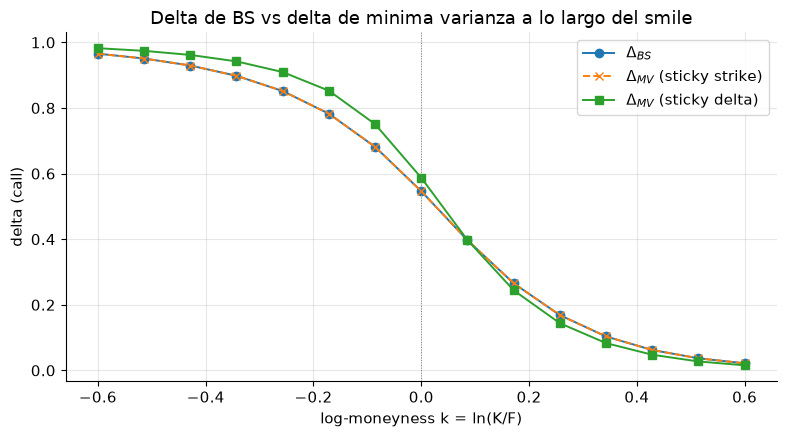

maxima separacion |delta_mv(sticky delta) - delta_bs|: 0.0702
separacion en K=120 (call OTM, cola derecha): -0.02257 (negativa: domina la curvatura de la cola derecha, no el skew ATM)


In [9]:
S0 = F0
deltas_bs = np.array([
    bs_delta(S0, K, 0.0, 0.0, iv_from_k(np.log(K / S0)), T_cal, kind="call") for K in strikes
])
deltas_mv_strike = np.array([
    mv_delta(S0, K, 0.0, 0.0, iv_from_k(np.log(K / S0)), T_cal, regime="sticky_strike")
    for K in strikes
])
deltas_mv_delta = np.array([
    mv_delta(S0, K, 0.0, 0.0, iv_from_k(np.log(K / S0)), T_cal, regime="sticky_delta")
    for K in strikes
])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_obs, deltas_bs, "o-", label=r"$\Delta_{BS}$")
ax.plot(k_obs, deltas_mv_strike, "x--", label=r"$\Delta_{MV}$ (sticky strike)")
ax.plot(k_obs, deltas_mv_delta, "s-", label=r"$\Delta_{MV}$ (sticky delta)")
ax.axvline(0.0, color="gray", lw=0.7, ls=":")
ax.set_xlabel("log-moneyness k = ln(K/F)"); ax.set_ylabel("delta (call)")
ax.set_title("Delta de BS vs delta de minima varianza a lo largo del smile")
ax.legend(); fig.tight_layout(); plt.show()

print(f"maxima separacion |delta_mv(sticky delta) - delta_bs|: {np.max(np.abs(deltas_mv_delta - deltas_bs)):.4f}")
print(f"separacion en K=120 (call OTM, cola derecha): "
      f"{mv_delta(S0, 120.0, 0.0, 0.0, iv_from_k(np.log(120.0/S0)), T_cal, regime='sticky_delta') - bs_delta(S0, 120.0, 0.0, 0.0, iv_from_k(np.log(120.0/S0)), T_cal, kind='call'):.5f}"
      " (negativa: domina la curvatura de la cola derecha, no el skew ATM)")

### Demo 5 — cuál delta cubre mejor bajo una dinámica sticky-delta

La pregunta que le da nombre al delta de mínima varianza es empírica, no solo analítica: si el mercado efectivamente se comporta como sticky-delta (el smile viaja con el spot), ¿el hedge con $\Delta_{MV}$ realmente reduce la varianza del P&L de cobertura frente a $\Delta_{BS}$? Simulamos `n_paths` trayectorias del spot con vol realizada constante (igual a la vol implícita ATM del smile calibrado, para no mezclar el efecto de vol mal especificada de 03.2 con el efecto de smile que nos interesa aquí), rebalanceando el hedge diariamente sobre un call OTM ($K=120$, $F_0=100$) durante un mes. En cada paso repreciamos la opción y recalculamos ambos deltas usando la vol implícita que le corresponde al strike bajo la regla sticky-delta (la MISMA superficie SVI calibrada, evaluada en el $k$ que corresponde al spot de ese paso) — es decir, el smile se mueve exactamente como predice 3.2, y comparamos qué delta absorbe mejor ese movimiento. `qflib.black` no acepta arrays, así que para vectorizar sobre miles de trayectorias replicamos aquí, en una sola celda, las mismas fórmulas de precio/delta/vega de Black-Scholes ya usadas (call, $q=0$) — no es un modelo nuevo, es la misma fórmula vectorizada.

La corrección que de verdad se usa en las mesas de opciones no es esta hipótesis sticky-delta pura, sino la fórmula empírica de Hull & White (2017): calibran $\partial\sigma_{\text{impl}}/\partial S$ por regresión histórica de cambios de vol implícita contra retornos del subyacente y la moneyness, sin comprometerse de antemano con sticky strike o sticky delta puros. La mencionamos aquí como el resultado con el que se ajustan en la práctica, sin rederivarla — es un resultado de calibración empírica, no una identidad de modelo.

In [10]:
def _d1(S, K, sigma, tau):
    return (np.log(S / K) + 0.5 * sigma ** 2 * tau) / (sigma * np.sqrt(tau))


def call_price_vec(S, K, sigma, tau):
    d1 = _d1(S, K, sigma, tau); d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * norm.cdf(d2)


def call_delta_vec(S, K, sigma, tau):
    return norm.cdf(_d1(S, K, sigma, tau))


def call_vega_vec(S, K, sigma, tau):
    return S * norm.pdf(_d1(S, K, sigma, tau)) * np.sqrt(tau)


K_hedge = 120.0
n_paths, n_steps, dt = 20_000, 21, 1.0 / 252
sigma_real = float(iv_from_k(0.0))  # vol ATM del smile calibrado, usada como vol realizada

S = np.full(n_paths, F0)
tau = T_cal
pnl_bs = np.zeros(n_paths)
pnl_mv = np.zeros(n_paths)
for _ in range(n_steps):
    k = np.log(K_hedge / S)
    sigma_i = iv_from_k(k)
    delta_bs_i = call_delta_vec(S, K_hedge, sigma_i, tau)
    vega_i = call_vega_vec(S, K_hedge, sigma_i, tau)
    dsig_i = div_dk(k) * (-1.0 / S)  # sticky delta, vectorizado (misma formula que dsigma_dS)
    delta_mv_i = delta_bs_i + vega_i * dsig_i
    V_i = call_price_vec(S, K_hedge, sigma_i, tau)

    Z = rng.standard_normal(n_paths)
    S_next = S * np.exp(-0.5 * sigma_real ** 2 * dt + sigma_real * np.sqrt(dt) * Z)
    tau_next = tau - dt
    sigma_next = iv_from_k(np.log(K_hedge / S_next))
    V_next = call_price_vec(S_next, K_hedge, sigma_next, tau_next)

    pnl_bs += delta_bs_i * (S_next - S) - (V_next - V_i)
    pnl_mv += delta_mv_i * (S_next - S) - (V_next - V_i)
    S, tau = S_next, tau_next

var_bs = pnl_bs.var(ddof=1)
var_mv = pnl_mv.var(ddof=1)

# reduccion de varianza pareada por trayectoria (no fragil a una sola corrida: se reporta con su error estandar)
d_sq = (pnl_bs - pnl_bs.mean()) ** 2 - (pnl_mv - pnl_mv.mean()) ** 2
var_reduction = d_sq.mean()
se_reduction = d_sq.std(ddof=1) / np.sqrt(len(d_sq))
z_reduction = var_reduction / se_reduction

print(f"Var(PnL hedge con Delta_BS): {var_bs:.5f}")
print(f"Var(PnL hedge con Delta_MV): {var_mv:.5f}")
print(f"reduccion relativa de varianza: {1 - var_mv / var_bs:.1%}")
print(f"reduccion de varianza: {var_reduction:.5f} +/- {se_reduction:.5f} (z={z_reduction:.1f})")

Var(PnL hedge con Delta_BS): 0.02253
Var(PnL hedge con Delta_MV): 0.01178
reduccion relativa de varianza: 47.7%
reduccion de varianza: 0.01076 +/- 0.00025 (z=43.1)


## 4. Validación

Cuatro chequeos: (1) y (2) la superficie arbitrage-free de la Demo 1 pasa calendario y butterfly en toda la malla; (3) la superficie con arbitraje de calendario intencional de la Demo 3 SÍ es detectada; (3b) el control negativo simétrico de butterfly (Demo 3b) también es detectado — `durrleman_g` da valores negativos y el chequeo la rechaza; (4) la recalibración de SVI de la Sección 2 recupera los 5 parámetros verdaderos dentro de 1% de error relativo. Cuatro chequeos adicionales sobre la Sección 3: (5) identidad exacta $\Delta_{MV}=\Delta_{BS}$ bajo sticky strike; (6) idéntica identidad con una superficie sin smile ($b=0$); (7) $\Delta_{MV}<\Delta_{BS}$ para el call OTM de la Demo 4/5 bajo sticky delta con skew negativo; (8) la reducción de varianza del P&L de cobertura de la Demo 5 es significativa frente a su propio error estándar.

In [11]:
check1 = calendar_ok
print(f"1. superficie arbitrage-free pasa calendario: {check1}")

check2 = butterfly_ok
print(f"2. superficie arbitrage-free pasa butterfly (Durrleman) en todos los vencimientos: {check2}")

check3 = not calendar_bad_ok
print(f"3. superficie CON arbitraje de calendario intencional SI es detectada (calendario falla): {check3}")

check3b = not butterfly_bad_ok
print(f"3b. superficie CON arbitraje de mariposa intencional SI es detectada (Durrleman g<0): {check3b} "
      f"(min g={g_bad.min():.4f})")

check4 = np.all(rel_err < 0.01)
print(f"4. recalibracion SVI recupera los 5 parametros dentro de rtol=1%: {check4} (max err={rel_err.max():.2e})")

assert check1
assert check2
assert check3
assert check3b
assert check4
print("\nValidacion completa: 5/5 dentro de tolerancia.")

# --- Seccion 3: minimum variance delta ---

# 5. sticky strike: Delta_MV == Delta_BS de forma EXACTA (dsigma/dS=0 por construccion, no una aproximacion)
K5, S5 = 100.0, F0
sigma5 = float(iv_from_k(np.log(K5 / S5)))
delta_bs_5 = bs_delta(S5, K5, 0.0, 0.0, sigma5, T_cal, kind="call")
delta_mv_5 = mv_delta(S5, K5, 0.0, 0.0, sigma5, T_cal, regime="sticky_strike")
check5 = delta_mv_5 == delta_bs_5
print(f"5. sticky strike: Delta_MV == Delta_BS exactamente: {check5} "
      f"(Delta_BS={delta_bs_5:.10f}, Delta_MV={delta_mv_5:.10f})")

# 6. superficie plana (sin smile, b=0): incluso bajo sticky delta, dsigma/dS=0 y Delta_MV == Delta_BS
a_flat, b_flat, rho_flat, m_flat, sigma_flat = 0.04, 0.0, 0.0, 0.0, 0.2
sigma6 = float(iv_from_k(np.log(K5 / S5), a=a_flat, b=b_flat, rho=rho_flat, m=m_flat, sigma=sigma_flat))
dsig6 = div_dk(np.log(K5 / S5), a=a_flat, b=b_flat, rho=rho_flat, m=m_flat, sigma=sigma_flat) * (-1.0 / S5)
delta_bs_6 = bs_delta(S5, K5, 0.0, 0.0, sigma6, T_cal, kind="call")
delta_mv_6 = delta_bs_6 + bs_vega(S5, K5, 0.0, 0.0, sigma6, T_cal) * dsig6
check6 = np.isclose(delta_mv_6, delta_bs_6, atol=1e-10)
print(f"6. superficie plana (b=0), sticky delta: Delta_MV == Delta_BS: {check6} "
      f"(dsigma/dS={dsig6:.2e}, diff={delta_mv_6 - delta_bs_6:.2e})")

# 7. skew negativo + sticky delta: Delta_MV < Delta_BS para el call OTM (K=120) de la Demo 4/5
K7 = 120.0
sigma7 = float(iv_from_k(np.log(K7 / S0)))
delta_bs_7 = bs_delta(S0, K7, 0.0, 0.0, sigma7, T_cal, kind="call")
delta_mv_7 = mv_delta(S0, K7, 0.0, 0.0, sigma7, T_cal, regime="sticky_delta")
check7 = delta_mv_7 < delta_bs_7
print(f"7. sticky delta, call OTM K=120: Delta_MV < Delta_BS: {check7} "
      f"(Delta_BS={delta_bs_7:.4f}, Delta_MV={delta_mv_7:.4f})")

# 8. la reduccion de varianza del P&L de cobertura (Demo 5) es significativa: muchas desviaciones
#    estandar por encima de cero, no un artefacto de una sola corrida de Monte Carlo
check8 = (var_mv < var_bs) and (z_reduction > 5.0)
print(f"8. reduccion de varianza del hedge (Delta_MV vs Delta_BS) es significativa: {check8} "
      f"(reduccion={var_reduction:.5f}, se={se_reduction:.5f}, z={z_reduction:.1f})")

assert check5
assert check6
assert check7
assert check8
print("Seccion 3 (minimum variance delta): 4/4 chequeos adicionales dentro de tolerancia.")


1. superficie arbitrage-free pasa calendario: True
2. superficie arbitrage-free pasa butterfly (Durrleman) en todos los vencimientos: True
3. superficie CON arbitraje de calendario intencional SI es detectada (calendario falla): True
3b. superficie CON arbitraje de mariposa intencional SI es detectada (Durrleman g<0): True (min g=-2.7159)
4. recalibracion SVI recupera los 5 parametros dentro de rtol=1%: True (max err=1.05e-08)

Validacion completa: 5/5 dentro de tolerancia.
5. sticky strike: Delta_MV == Delta_BS exactamente: True (Delta_BS=0.5462488211, Delta_MV=0.5462488211)
6. superficie plana (b=0), sticky delta: Delta_MV == Delta_BS: True (dsigma/dS=-0.00e+00, diff=0.00e+00)
7. sticky delta, call OTM K=120: Delta_MV < Delta_BS: True (Delta_BS=0.2512, Delta_MV=0.2286)
8. reduccion de varianza del hedge (Delta_MV vs Delta_BS) es significativa: True (reduccion=0.01076, se=0.00025, z=43.1)
Seccion 3 (minimum variance delta): 4/4 chequeos adicionales dentro de tolerancia.


## Referencias

- Gatheral, J. (2004). *A parsimonious arbitrage-free implied volatility
  parameterization with application to the valuation of volatility derivatives*.
- Gatheral, J. & Jacquier, A. (2014). *Arbitrage-free SVI volatility surfaces*.
  Quantitative Finance, 14(1), 59-71.
- Hull, J. (latest ed.). *Options, Futures, and Other Derivatives*. Sección sobre el delta de mínima varianza ("minimum variance delta") y las hipótesis sticky strike / sticky delta.
- Hull, J. & White, A. (2017). *Optimal Delta Hedging for Options*. Journal of Banking and Finance, 82, 180-190. Ajuste empírico del delta de mínima varianza vía regresión histórica de cambios de vol implícita.